### Data Cleaning

In [161]:
# importing the required libraries  
import numpy as np
import pandas as pd

In [162]:
# reading the dataset
df = pd.read_csv('house_prices_raw.csv')
print(df.head())

   House_ID Area_sqft  Bedrooms  Bathrooms  Age_years    Location        Price
0        23    1549.0         3       2.00      33.00  Bangalore  5,932,000.00
1        47     934.0         2       1.00       0.00      mumbai 3,563,000.00
2        81    1555.0         2       1.00      17.00      Nagpur 5,956,000.00
3        94    1496.0         4       4.00      16.00  Bangalore  6,306,000.00
4        44    2377.0         2       2.00      36.00   Bangalore 8,430,000.00


In [163]:
# statistical summary of the dataset
print("Description of the dataset:")
pd.set_option('display.float_format', '{:,.2f}'.format)
print(df.describe())
print("\nDataset information:")
print(df.info())
print("\nNumber of missing values in each column:")
print(df.isnull().sum())

Description of the dataset:
       House_ID  Bedrooms  Bathrooms  Age_years         Price
count    104.00    104.00      99.00     101.00        104.00
mean      51.27      2.78       2.34      20.81  4,885,730.77
std       29.00      1.18       1.12      11.39  1,980,278.11
min        1.00      1.00       1.00      -5.00  2,139,000.00
25%       26.75      2.00       1.00      11.00  3,561,250.00
50%       51.50      3.00       2.00      22.00  4,517,500.00
75%       77.25      4.00       3.00      31.00  5,715,000.00
max      100.00      5.00       5.00      39.00 15,000,000.00

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   House_ID   104 non-null    int64  
 1   Area_sqft  98 non-null     str    
 2   Bedrooms   104 non-null    int64  
 3   Bathrooms  99 non-null     float64
 4   Age_years  101 non-null    float64
 5   Location   100

In [ ]:
# dropping dulicate rows from the dataset
df = df.drop_duplicates()

,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_years,Location,Price
0,23,1549.0,3,2.00,33.00,Bangalore,"5,932,000.00"
1,47,934.0,2,1.00,0.00,mumbai,"3,563,000.00"
2,81,1555.0,2,1.00,17.00,Nagpur,"5,956,000.00"
3,94,1496.0,4,4.00,16.00,Bangalore,"6,306,000.00"
4,44,2377.0,2,2.00,36.00,Bangalore,"8,430,000.00"
...,...,...,...,...,...,...,...
99,84,1092.0,4,4.00,23.00,Mumbai,"4,192,000.00"
100,68,933.0,3,3.00,10.00,Delhi,"3,799,000.00"
101,26,1529.0,3,3.00,18.00,Mumbai,"6,134,000.00"
102,69,1145.0,4,4.00,28.00,Nagpur,"4,707,000.00"


In [165]:
# converting the column names to lowercase
df.columns = df.columns.str.lower()
print("\nColumn names after converting to lowercase:")
print(df.columns)
df['area_sqft'] = df['area_sqft'].str.replace(' sqft', '').astype(float)
print(df['area_sqft'].dtype)


Column names after converting to lowercase:
Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'age_years',
       'location', 'price'],
      dtype='str')
float64


In [166]:
# making values consistent in the 'location' column by converting them to lowercase and removing any whitespace
print(df['location'].unique())
df['location'] = df['location'].astype(str).str.lower().replace(r'\s+','',regex = True)

# checking the unique values in the 'location' column after making them consistent
print(df['location'].unique())

<StringArray>
['Bangalore ',     'mumbai',     'Nagpur',  'Bangalore',     'Mumbai',
      'Delhi',      'Thane',       'Pune',     'Nashik',      'pune ',
          nan]
Length: 11, dtype: str
<StringArray>
['bangalore', 'mumbai', 'nagpur', 'delhi', 'thane', 'pune', 'nashik', nan]
Length: 8, dtype: str


In [167]:
# handling missing values
df['location'] = df['location'].fillna(df['location'].mode()[0])
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].mode()[0])
df['age_years'] = df['age_years'].fillna(df['age_years'].median())
df['area_sqft'] = df['area_sqft'].fillna(df['area_sqft'].median())

# checking for missing values after handling them 
print(df.isnull().sum())

house_id     0
area_sqft    0
bedrooms     0
bathrooms    0
age_years    0
location     0
price        0
dtype: int64


In [168]:
# adjust the negative values in the 'age_years' column to 0
df['age_years'] = df['age_years'].apply(lambda x: 0 if x < 0 else x)

In [169]:
# saving the cleaned dataset to a new CSV file
df.to_csv('house_prices_cleaned.csv', index=False)

### EDA Exploratory Data Analysis


 "The dataset contains some unrealistic property configurations (e.g., 5 BHK in 600 sq ft), but these were retained because there is no evidence they are data-entry errors."

In [170]:
# importing the required libraries
import seaborn as sns
import matplotlib.pyplot as plt

In [171]:
# loading the cleaned dataset
df = pd.read_csv('house_prices_cleaned.csv')

In [172]:
print(df.describe())

       house_id  area_sqft  bedrooms  bathrooms  age_years         price
count    104.00     104.00    104.00     104.00     104.00        104.00
mean      51.27   1,282.14      2.78       2.28      20.89  4,885,730.77
std       29.00     902.26      1.18       1.13      11.12  1,980,278.11
min        1.00     424.00      1.00       1.00       0.00  2,139,000.00
25%       26.75     906.50      2.00       1.00      11.00  3,561,250.00
50%       51.50   1,160.50      3.00       2.00      22.00  4,517,500.00
75%       77.25   1,494.50      4.00       3.00      30.25  5,715,000.00
max      100.00   9,500.00      5.00       5.00      39.00 15,000,000.00


In [173]:
df["price_per_sqft"] = (df["price"] / df["area_sqft"])

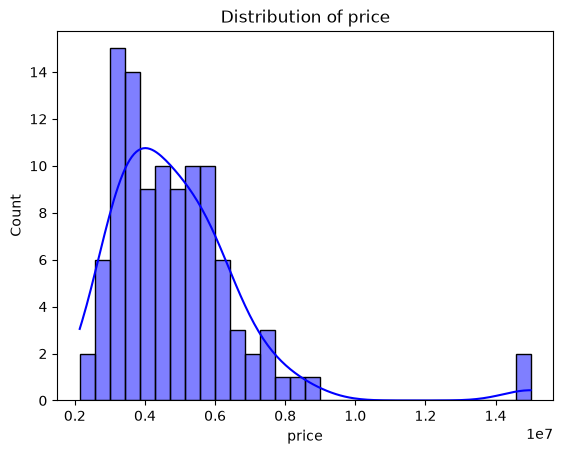

In [174]:
# distribution of the target variable 'price'
(sns
 .histplot(df['price'], kde = True, color = 'blue', bins = 30)
 .title.set_text('Distribution of price')
 )

 the distribution of the target variable 'price' is right-skewed, which indicates that there are some high-priced houses in the dataset. 

<Axes: xlabel='price'>

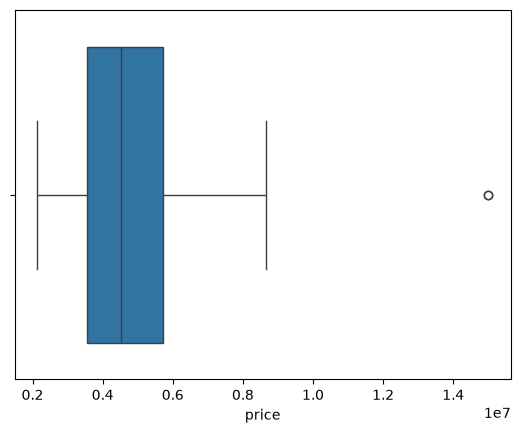

In [175]:
# checking the boxplot for the 'price' column to identify any outliers
sns.boxplot(x = 'price', data = df)

In [176]:
#  checking the largest area_sqft values in the dataset for the location 'bangalore'
print("Checking the largest area_sqft values in the dataset for the location 'bangalore': ")
df[df['location'] == 'bangalore'].sort_values(by = 'area_sqft', ascending = False)

Checking the largest area_sqft values in the dataset for the location 'bangalore': 


,house_id,area_sqft,bedrooms,bathrooms,age_years,location,price,price_per_sqft
4,44,"2,377.00",2,2.00,36.00,bangalore,"8,430,000.00","3,546.49"
25,6,"1,891.00",4,3.00,4.00,bangalore,"7,329,000.00","3,875.73"
73,25,"1,849.00",5,4.00,9.00,bangalore,"7,319,000.00","3,958.36"
75,70,"1,761.00",1,1.00,35.00,bangalore,"5,824,000.00","3,307.21"
28,97,"1,600.00",3,2.00,21.00,bangalore,"6,205,000.00","3,878.12"
0,23,"1,549.00",3,2.00,33.00,bangalore,"5,932,000.00","3,829.57"
48,77,"1,516.00",4,3.00,23.00,bangalore,"5,894,000.00","3,887.86"
3,94,"1,496.00",4,4.00,16.00,bangalore,"6,306,000.00","4,215.24"
5,82,"1,442.00",2,2.00,38.00,bangalore,"5,189,000.00","3,598.47"
72,82,"1,442.00",2,2.00,38.00,bangalore,"15,000,000.00","10,402.22"


 this data helps to understand what are the general rate of the houses in Bangalore and concluding that the house with the house price of 1.5 crore and area of 607 sqft that feels odd as compared to other houses in the same location. So we can remove this data point from the dataset as it is an outlier.

In [177]:
mask = (df['area_sqft'] == 607) & (df['price'] == 15_000_000)
data = df[mask]
df.drop(index=data.index, inplace=True)

<Axes: xlabel='area_sqft'>

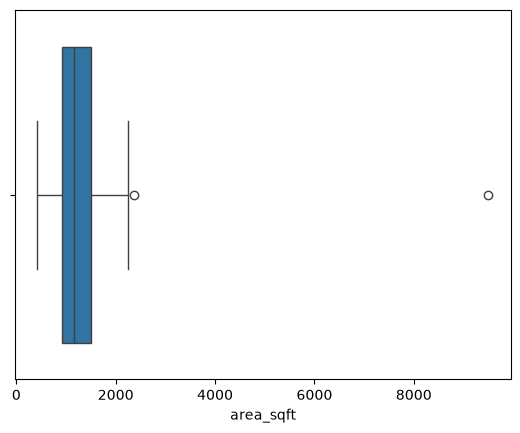

In [178]:
sns.boxplot(x = 'area_sqft', data = df)

In [179]:
# checking the largest area_sqft values in the dataset only for the location
print("Checking the largest area_sqft values in the dataset:")
df.sort_values(by ='area_sqft',ascending = False).head(10)

Checking the largest area_sqft values in the dataset:


,house_id,area_sqft,bedrooms,bathrooms,age_years,location,price,price_per_sqft
9,89,"9,500.00",4,4.00,12.00,delhi,"6,472,000.00",681.26
4,44,"2,377.00",2,2.00,36.00,bangalore,"8,430,000.00","3,546.49"
20,19,"2,253.00",5,4.00,22.00,nashik,"8,649,000.00","3,838.88"
98,24,"2,115.00",2,2.00,30.00,nashik,"7,467,000.00","3,530.50"
70,62,"1,990.00",4,3.00,25.00,nashik,"7,749,000.00","3,893.97"
45,63,"1,986.00",1,1.00,9.00,mumbai,"7,239,000.00","3,645.02"
25,6,"1,891.00",4,3.00,4.00,bangalore,"7,329,000.00","3,875.73"
73,25,"1,849.00",5,4.00,9.00,bangalore,"7,319,000.00","3,958.36"
22,3,"1,788.00",3,2.00,28.00,delhi,"6,970,000.00","3,898.21"
75,70,"1,761.00",1,1.00,35.00,bangalore,"5,824,000.00","3,307.21"


In [180]:
# checking the largest area_sqft values in the dataset only for the location 'delhi'
print("Checking the largest area_sqft values in the dataset for the location 'delhi': ")
df[df['location'] == 'delhi'].sort_values(by = 'area_sqft', ascending = False).head(10)

Checking the largest area_sqft values in the dataset for the location 'delhi': 


,house_id,area_sqft,bedrooms,bathrooms,age_years,location,price,price_per_sqft
9,89,"9,500.00",4,4.00,12.00,delhi,"6,472,000.00",681.26
22,3,"1,788.00",3,2.00,28.00,delhi,"6,970,000.00","3,898.21"
54,55,"1,635.00",1,1.00,1.00,delhi,"5,911,000.00","3,615.29"
17,12,"1,494.00",3,2.00,25.00,delhi,"5,587,000.00","3,739.63"
49,86,"1,447.00",5,5.00,31.00,delhi,"6,012,000.00","4,154.80"
89,9,"1,331.00",3,2.00,11.00,delhi,"5,313,000.00","3,991.74"
67,75,"1,211.00",2,2.00,22.00,delhi,"3,848,000.00","3,177.54"
23,18,"1,155.00",2,1.00,36.00,delhi,"4,334,000.00","3,752.38"
26,85,"1,143.00",1,1.00,22.00,delhi,"3,737,000.00","3,269.47"
77,85,"1,143.00",1,1.00,22.00,delhi,"3,737,000.00","3,269.47"


In [181]:
# removing the suspicious data point with price 6,472,000.00 from the dataset
df.drop(index=df[df['price'] == 6_472_000.00].index, inplace=True)

 Removing a suspicious record where the property has an unusually large area
 (9500 sqft) but a comparatively low price. Based on price-per-sqft analysis
 and comparison with other Delhi properties, this record appears inconsistent
 with the rest of the dataset.

<Axes: xlabel='area_sqft'>

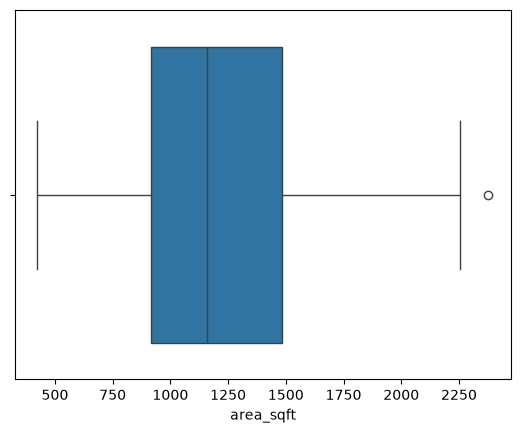

In [182]:
# checking the boxplot again for the 'area_sqft' column after removing the suspicious data point
sns.boxplot(x = 'area_sqft', data = df)

 the outlier now looks like a reasonable value for the 'area_sqft' column. We can now proceed to check the largest area_sqft values in the dataset.

In [183]:
print("Checking the largest area_sqft values in the dataset: ")
print(df.sort_values(by ='area_sqft',ascending = False).head(10))

Checking the largest area_sqft values in the dataset: 
    house_id  area_sqft  bedrooms  bathrooms  age_years   location  \
4         44   2,377.00         2       2.00      36.00  bangalore   
20        19   2,253.00         5       4.00      22.00     nashik   
98        24   2,115.00         2       2.00      30.00     nashik   
70        62   1,990.00         4       3.00      25.00     nashik   
45        63   1,986.00         1       1.00       9.00     mumbai   
25         6   1,891.00         4       3.00       4.00  bangalore   
73        25   1,849.00         5       4.00       9.00  bangalore   
22         3   1,788.00         3       2.00      28.00      delhi   
75        70   1,761.00         1       1.00      35.00  bangalore   
58        87   1,700.00         3       1.00      36.00       pune   

          price  price_per_sqft  
4  8,430,000.00        3,546.49  
20 8,649,000.00        3,838.88  
98 7,467,000.00        3,530.50  
70 7,749,000.00        3,893.97  
45 7